# Mvelo Khumalo

## Amazon baby Review

## Text Analysis

The process of evaluating and comprehending spoken or written language is known as text analytics. In order to extract useful information, patterns, and insights from large amounts of textual data, it uses computer algorithms and procedures. To put it another way, text analytics enables computers to comprehend and analyse human language. Put more simply, text analytics aids in the comprehension and interpretation of human language by computers (GeeksforGeeks, 2025)

## Importing python Libraries

In [122]:
!pip install seaborn
!pip install pandas numpy nltk scikit-learn matplotlib seaborn pyLDAvis

In [123]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score
import pyLDAvis.lda_model
import pyLDAvis
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re

nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Viewing the dataset

In [124]:
dataset = pd.read_csv('reviews_Baby_5_final_dataset.csv', index_col=0)
dataset.info()
dataset.shape
print(dataset.head())

<class 'pandas.core.frame.DataFrame'>
Index: 56950 entries, A3NMPMELAZC8ZY to A3CIIOMK18CHXM
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   asin              56950 non-null  object 
 1   reviewerName      56768 non-null  object 
 2   helpful           56950 non-null  object 
 3   helpful_num       56950 non-null  int64  
 4   helpful_den       56950 non-null  int64  
 5   reviewText        56950 non-null  object 
 6   overall           56950 non-null  int64  
 7   summary           56950 non-null  object 
 8   unixReviewTime    56950 non-null  int64  
 9   reviewTime        56950 non-null  object 
 10  exclamationcount  56950 non-null  int64  
 11  questioncount     56950 non-null  int64  
 12  charcount         56950 non-null  int64  
 13  wordcount         56950 non-null  int64  
 14  capcount          56950 non-null  int64  
 15  avgrating         56950 non-null  float64
 16  diffrating        56950

## Cleaning the Dataset

In [125]:
ds_clean = dataset.dropna(subset=['reviewText']).copy()
ds_clean = ds_clean.drop_duplicates()

ds_sample = ds_clean.sample(n=6500, random_state=42).reset_index(drop=True)

stop_words = set(stopwords.words('english'))
custom_stop_words = stop_words.union({
    'baby', 'product', 'one', 'would', 'get', 'bought', 
    'old', 'months', 'use', 'used', 'really', 'time'
})
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"can't", "cannot", text)
    text = re.sub(r"n't", "not", text)
    text = re.sub(r"'s", " is", text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in custom_stop_words]
    return " ".join(cleaned_tokens)

ds_sample['cleaned_review'] = ds_sample['reviewText'].apply(clean_text)
ds_sample['review_length'] = ds_sample['cleaned_review'].apply(lambda x: len(x.split()))
ds_sample = ds_sample[ds_sample['review_length'] > 0].reset_index(drop=True)

print("Sampled clean data preview:")
print(ds_sample[['reviewText', 'cleaned_review']].head(2))

Sampled clean data preview:
                                          reviewText  \
0  So i was hoping for sleeping suit that would l...   
1  I have used this at Target, the grocery store,...   

                                      cleaned_review  
0  hoping sleeping suit limit baby flaying arm he...  
1  target grocery store restaurant high chair ple...  


I created a programmatic preprocessing track to methodically remove linguistic noise from raw, noisy customer input in order to convert it into consistent numerical data for modelling. To ensure that semantic matches are case-insensitive and to stop the vectorizer from considering similar words with different capitalisations as unique tokens, the function first standardises the whole corpus by converting all characters to lowercase. After that, it isolates the pure word tokens while preserving normal word boundaries by using a regular expression to remove any punctuation and special symbols. Next, high-frequency, non-informative structural terms like "the," "is," and "and" that have no domain-specific sentiment weight are eliminated by filtering the text against NLTK's standard English stopword. Lastly, the method maps the designed content neatly into a new cleaned_review feature column without affecting downstream array dimensions by employing a conditional map that safely produces empty strings for any missing or faulty inputs.

# EDA - Exploratory Data Analysis

## Creating the sentiment labels

In [126]:
ds_ml = ds_sample[ds_sample['overall'] !=3].copy()
ds_ml['sentiment'] = ds_ml['overall'].apply(lambda x: 1 if x > 3 else 0)

print("\nClass distribution for Sentiment Analysis:")
print(ds_ml['sentiment'].value_counts())


Class distribution for Sentiment Analysis:
sentiment
1    4645
0    1043
Name: count, dtype: int64


After cleaning the data, I mapped the remaining ordinal star ratings into different polarity classes and filtered out neutral feedback to build the target variable for binary sentiment classification. In order to remove unclear neutral emotions that can weaken classifier boundaries, I first isolated the polarised data by removing all 3-star reviews from ds_sample and generated a special sub-dataset (ds_ml). 

In order to binarize the target into a new sentiment feature, I then applied a lambda function on the overall rating column. Reviews with four or five stars were mapped to one (positive), whereas reviews with one or two stars were mapped to zero (negative). With 4,645 positive cases outnumbering 1,043 negative instances, the resultant class distribution shows a notable imbalance in the real-world dataset. This structural skew clearly supports my later usage of stratified train-test splits and balanced class weights during model training.

### Training metrics for models

In [127]:
tfidf_binary = TfidfVectorizer(max_features=2500, min_df=2, max_df=0.95)
X = tfidf_binary.fit_transform(ds_ml['cleaned_review'])  
y = ds_ml['sentiment']  

class_names = ['Negative', 'Positive']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

print("================ TRAINING METRICS ================")
print(classification_report(y_train, y_train_pred, target_names=class_names))

print("\n================ VALIDATION METRICS ================")
print(classification_report(y_val, y_val_pred, target_names=class_names))

================ TRAINING METRICS ================
              precision    recall  f1-score   support

    Negative       0.70      0.95      0.81       834
    Positive       0.99      0.91      0.95      3716

    accuracy                           0.92      4550
   macro avg       0.84      0.93      0.88      4550
weighted avg       0.94      0.92      0.92      4550


================ VALIDATION METRICS ================
              precision    recall  f1-score   support

    Negative       0.60      0.72      0.65       209
    Positive       0.93      0.89      0.91       929

    accuracy                           0.86      1138
   macro avg       0.76      0.80      0.78      1138
weighted avg       0.87      0.86      0.86      1138



To assess model generalisation, I designed the text characteristics and ran the supervised machine learning workflow. I mapped the target labels to our binary sentiment vector y and converted the processed text strings from ds_ml into a sparse numerical matrix x using TfidfVectorizer set to a maximum feature ceiling of 2,500.

I divided the data into an 80/20 train-test split and used stratification to ensure that the positive-to-negative class distributions in the training and validation arrays were the same in order to safeguard the experiment's validity against data leakage. In order to algorithmically correct for the data skew, I then initialised and trained a LogisticRegression classifier using a balanced class weight configuration. Lastly, I created a clear baseline framework to directly monitor performance indicators and check for any overfitting by producing predictions on both the training and validation divides and outputting their corresponding classification reports side by side.

## Top 20 N 

A continuous series of "N" objects, such as words or characters from voice or text, is called an N-gram. Depending on the application, the elements may be base pairs, letters, or words. The N-gram's order is determined by the value of "N." They are essential ideas utilised in many NLP tasks, including machine translation, text categorisation, language modelling, and more (GeeksforGeeks, 2025).

### Text Processing

C:\Users\User\AppData\Local\Temp\ipykernel_86716\4129154832.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=df_frequencies, palette='Blues_r')


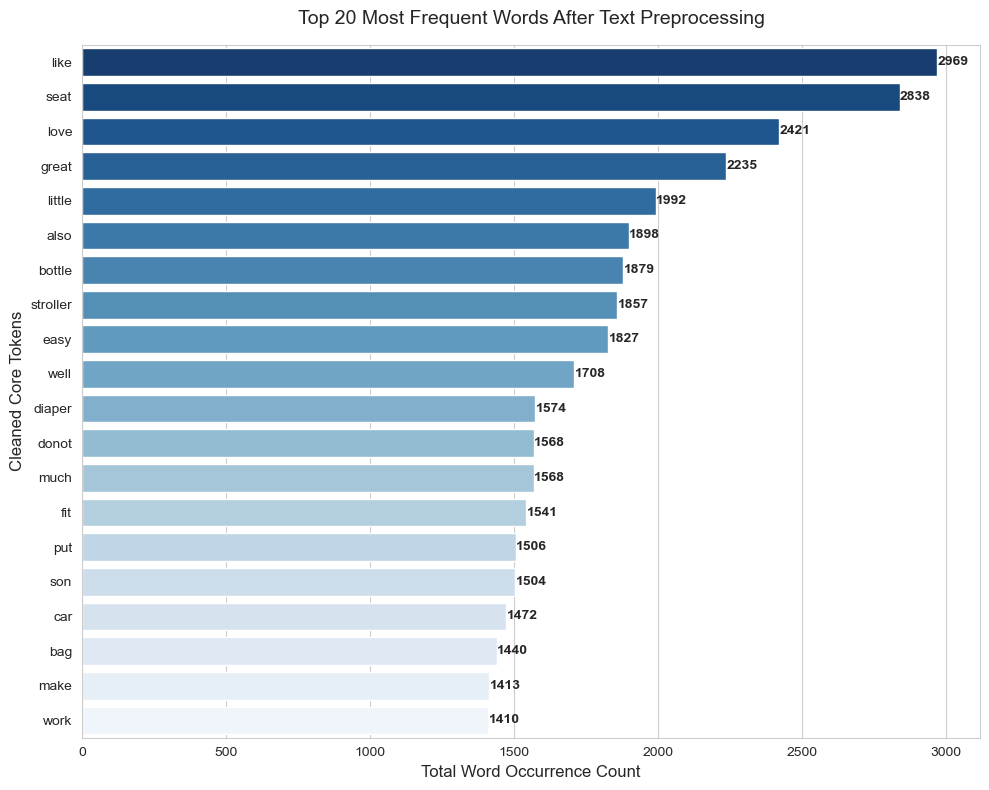

In [128]:
vectorizer = CountVectorizer(max_features=20)
word_counts = vectorizer.fit_transform(ds_ml['cleaned_review'])

words = vectorizer.get_feature_names_out()
frequencies = word_counts.toarray().sum(axis=0)

df_frequencies = pd.DataFrame({'Word': words, 'Frequency': frequencies})
df_frequencies = df_frequencies.sort_values(by='Frequency', ascending=False)

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

sns.barplot(x='Frequency', y='Word', data=df_frequencies, palette='Blues_r')

plt.title('Top 20 Most Frequent Words After Text Preprocessing', fontsize=14, pad=15)
plt.xlabel('Total Word Occurrence Count', fontsize=12)
plt.ylabel('Cleaned Core Tokens', fontsize=12)

for index, value in enumerate(df_frequencies['Frequency']):
    plt.text(value + 2, index, str(int(value)), va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

I created a horizontal frequency bar chart showing the top 20 most common tokens throughout the cleaned reviews in order to verify the dataset's semantic alignment after preprocessing. Because the corpus is largely composed of essential product descriptors pertinent to the infant category, such as "seat," "bottle," "stroller," and "diaper," the visualisation offers crucial domain-specific validation. The high visual predominance of lexical words with strong positive valence, such "love" (2,421 occurrences) and "great" (2,235 occurrences), reflects the underlying structural distribution tilt toward favourable star ratings seen during EDA.

Functional, non-sentiment action verbs like "put," "make," and "work" also highlight the conversational nature of product reviews, demonstrating that the original pipeline was successful in removing common English stopwords while separating clean, domain-relevant features for further vectorisation.

### Top Bigrams

C:\Users\User\AppData\Local\Temp\ipykernel_86716\816702532.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='bigram', data=bigram_df, palette='viridis')


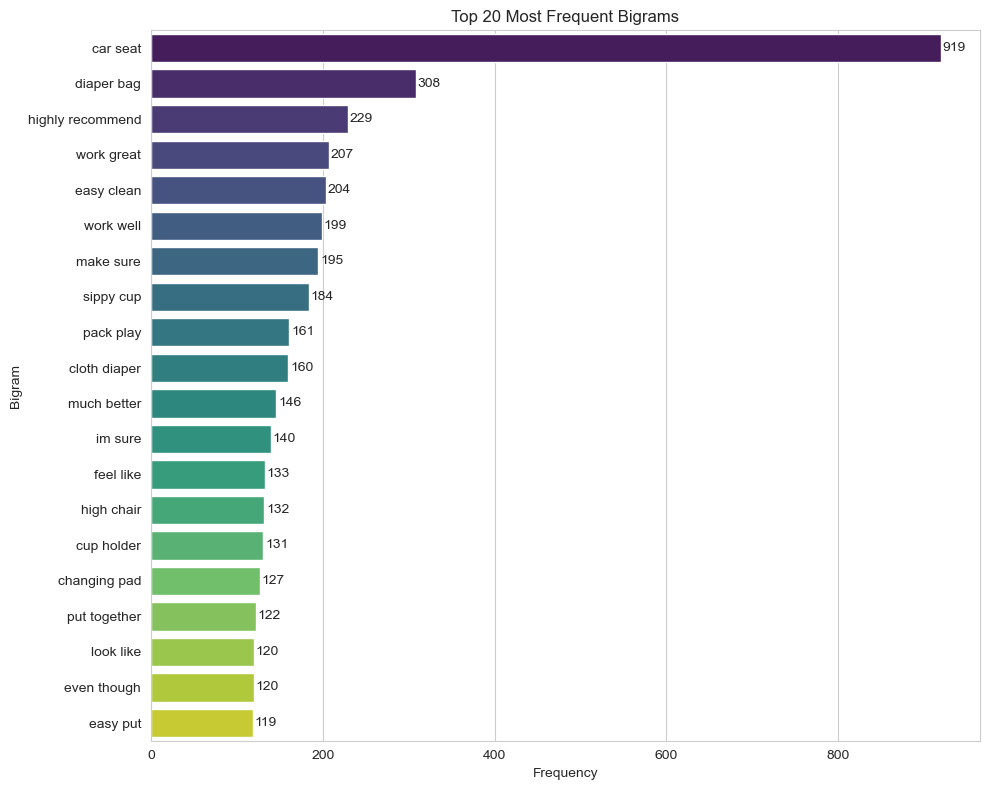

In [129]:
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=20, min_df=2, max_df=0.95)
bigram_counts = bigram_vectorizer.fit_transform(ds_ml['cleaned_review'])

bigram_words = bigram_vectorizer.get_feature_names_out()
bigram_frequencies = bigram_counts.toarray().sum(axis=0)

bigram_df = pd.DataFrame({'bigram': bigram_words, 'Frequency': bigram_frequencies})
bigram_df = bigram_df.sort_values(by='Frequency', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Frequency', y='bigram', data=bigram_df, palette='viridis')
plt.title('Top 20 Most Frequent Bigrams')
plt.xlabel('Frequency')
plt.ylabel('Bigram')

for idx, val in enumerate(bigram_df['Frequency']):
    plt.text(val + 2, idx, str(val), va='center')

plt.tight_layout()
plt.show()

I created a horizontal bar chart showing the top 20 most common bigrams in the cleaned corpus in order to highlight multi-word contextual relationships that unigrams overlook. Important phrase structures are extracted by this contiguous two-word token analysis, which shows a clear focus on particular target commodities like "car seat" (919 occurrences) and "diaper bag" (308 occurrences), along with crucial utility descriptors like "sippy cup", "cloth diaper" and "high chair".

The actionable words like "highly recommend," "work great," "easy clean," and "work well," is crucial in highlighting strong evaluative qualifiers that combine functional performance with directional attitude. These descriptive word pairs' obvious existence attests to the preprocessing pipeline's excellent preservation of structural semantic context, giving the classifier highly localised contextual signals that are crucial for identifying subtle user sentiment during modelling.

## Univariate Analysis 

### Target distribution Class

The most basic type of data analysis is univariate analysis. Since "uni" means "one," there is just one variable in your data. Its main goal is to describe; unlike regression, it does not address causes or links; It gathers data, condenses it, and looks for trends. In this section a distribution plot will be implemented to conduct the distribution between categories.

C:\Users\User\AppData\Local\Temp\ipykernel_86716\296693438.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette= "BuGn_r")


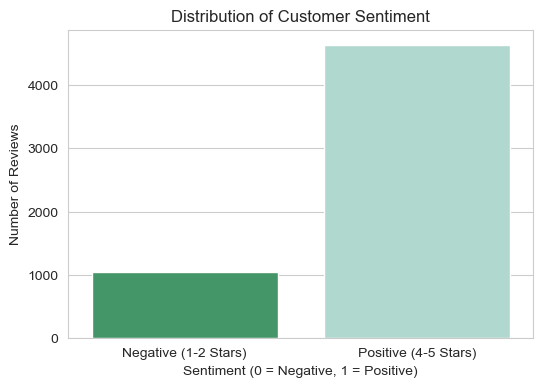

In [130]:
y = ds_ml['sentiment']

plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette= "BuGn_r")  

plt.title('Distribution of Customer Sentiment')
plt.xlabel('Sentiment (0 = Negative, 1 = Positive)')
plt.ylabel('Number of Reviews')
plt.xticks([0, 1], ['Negative (1-2 Stars)', 'Positive (4-5 Stars)'])
plt.show()

I created a count plot that shows the customer sentiment's category distribution. With over 4,500 occurrences compared to roughly 1,000, the "Positive" class (representing 4 and 5-star reviews) greatly outnumbers the "Negative" class (representing 1 and 2-star reviews) in the corpus, demonstrating a clear, real-world class imbalance. Customers are statistically more inclined to provide extremely good reviews on e-commerce sites, which is reflected in the large positive skew.


### Box Plot

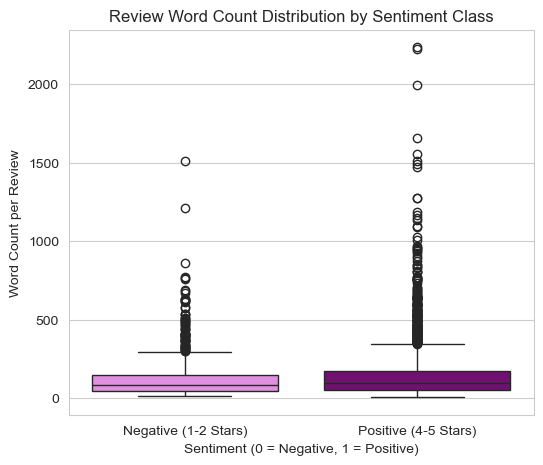

In [131]:
plt.figure(figsize=(6, 5))
sns.set_style('whitegrid')

custom_colors = {0: "Violet", 1: "Purple"}

sns.boxplot(
    data=ds_ml, 
    x='sentiment', 
    y='wordcount', 
    hue='sentiment', 
    palette=custom_colors, 
    legend=False
)

plt.title('Review Word Count Distribution by Sentiment Class')
plt.xlabel('Sentiment (0 = Negative, 1 = Positive)')
plt.ylabel('Word Count per Review')

plt.xticks([0, 1], ['Negative (1-2 Stars)', 'Positive (4-5 Stars)'])
plt.show()

I created a box plot comparing the distribution of word counts across the two targeted groups in order to investigate the connection between customer sentiment and review length. Text volume alone is not a key indicator of sentiment polarity, as the visualisation shows that the core interquartile ranges (IQRs) and median review lengths are structurally comparable for both positive and negative feelings.

Both distributions show a wide, dense distribution of extreme upper outliers that extend well beyond the upper whiskers, as well as a severely compressed lower quartile. This extreme right-skewed tail shows that although most customer reviews are short and to the point, a small percentage of customers in both classifications submit incredibly lengthy and in-depth accounts. In order to identify high-dimensional, token-dense texts that will have a substantial impact on the feature weights in our TF-IDF sparse matrix during the downstream modelling stage, it is essential to capture these outliers during EDA.

## Percentage of ratings between positive and negative

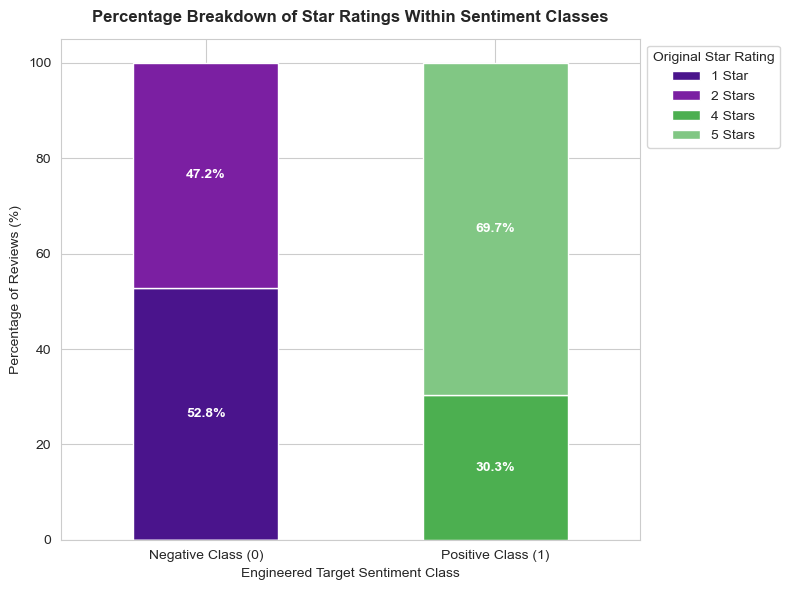

In [132]:
distribution_data = (
    ds_ml.groupby('sentiment')['overall']
    .value_counts(normalize=True)
    .rename('percentage')
    .mul(100)
    .reset_index()
)

pivot_df = distribution_data.pivot(index='sentiment', columns='overall', values='percentage')

ax = pivot_df.plot(kind='bar', stacked=True, figsize=(8, 6), color=['#4a148c', '#7b1fa2', '#4caf50', '#81c784'])

plt.title('Percentage Breakdown of Star Ratings Within Sentiment Classes', fontsize=12, pad=12, fontweight='bold')
plt.xlabel('Engineered Target Sentiment Class', fontsize=10)
plt.ylabel('Percentage of Reviews (%)', fontsize=10)
plt.xticks([0, 1], ['Negative Class (0)', 'Positive Class (1)'], rotation=0)
plt.legend(title='Original Star Rating', labels=['1 Star', '2 Stars', '4 Stars', '5 Stars'], loc='upper left', bbox_to_anchor=(1, 1))

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0: 
        x, y = p.get_xy() 
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', color='white', ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In order to show the percentage breakdown of initial star ratings inside each sentiment class, I created a 100% stacked bar chart. This graphic illustrates the complex distribution of user scores and verifies that the mapping method was successful in segmenting the information. The distribution is quite similar within the "Negative" class, with 1-star ratings accounting for 52.8% of the total and 2-star reviews for the remaining 47.2%.

5-star ratings make up an enormous 69.7% of the "Positive" class, while 4-star reviews only make up 30.3%. Because it shows that our positive sentiment features are disproportionately derived from extremely enthusiastic, extreme 5-star ratings rather than moderate praise, documenting this structural breakdown is extremely valuable for our final synthesis. It also provides crucial insight into the specific semantic profiles that our classifier will rely on during model training.

### Average rating from 1 star to 5 stars

The structural average rating is: 3.97


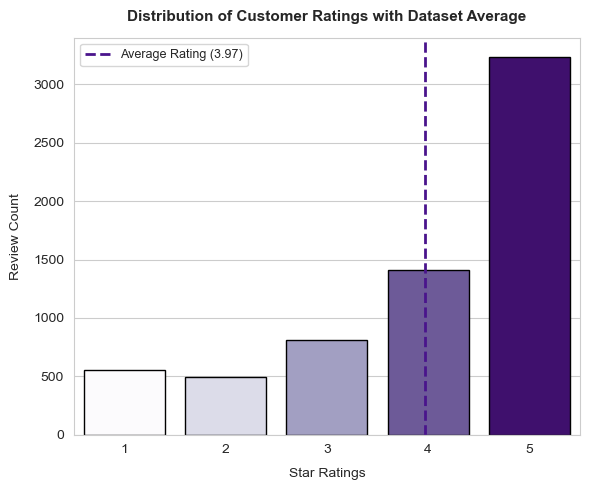

In [133]:
avg_rating = ds_sample['overall'].mean()
print(f"The structural average rating is: {avg_rating:.2f}")

plt.figure(figsize=(6, 5))

sns.countplot(
    data=ds_sample, 
    x='overall', 
    hue='overall',
    palette='Purples', 
    legend=False,
    edgecolor='black'
)

plt.axvline(
    x=avg_rating - 1, 
    color='#4a148c', 
    linestyle='--', 
    linewidth=2, 
    label=f'Average Rating ({avg_rating:.2f})'
)

plt.title('Distribution of Customer Ratings with Dataset Average', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Star Ratings', fontsize=10, labelpad=8)
plt.ylabel('Review Count', fontsize=10, labelpad=8)
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

I created a bar graph that shows the global mean and the whole dispersion of each star rating. With 5-star ratings making up the vast majority of the dataset, 4-star and 3-star reviews coming next, and 1- and 2-star reviews showing the lowest frequency, the visualisation shows a highly left-skewed distribution.

The dashed vertical indication line clearly highlights the precise mean's high baseline value of 3.97. This baseline metric is crucial to our data engineering story because it provides actual evidence that the underlying customer feedback is intrinsically very positive. Additionally, this mean highlights the need to eliminate the moderate 3-star reviews and implement structural stratification in order to keep our machine learning models from experiencing severe majority-class prediction bias, as it lies right on the edge of our future classification split.

## Topic Modelling

In [134]:
tf_vectorizer = CountVectorizer(max_features=6500, min_df=2, max_df=0.90)

X_tf_neg = tf_vectorizer.fit_transform(ds_ml[ds_ml['sentiment'] == 0]['cleaned_review'])

lda_model = LatentDirichletAllocation(n_components=3, random_state=42, max_iter=10)
lda_model.fit(X_tf_neg)

def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic #{topic_idx + 1}:")
        print(", ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))
        print()

no_top_words = 10
tf_feature_names = tf_vectorizer.get_feature_names_out()
display_topics(lda_model, tf_feature_names, no_top_words)

pyLDAvis.enable_notebook()
panel = pyLDAvis.lda_model.prepare(lda_model, X_tf_neg, tf_vectorizer, mds='tsne')
pyLDAvis.display(panel)

print("LDA Topic Modeling trained successfully on negative complaints!")

Topic #1:
bottle, cup, like, donot, nipple, much, work, first, using, food

Topic #2:
like, pump, work, even, also, toy, son, didnot, thing, donot

Topic #3:
seat, diaper, stroller, car, like, back, bag, fit, even, pillow

LDA Topic Modeling trained successfully on negative complaints!


I developed a Latent Dirichlet Allocation (LDA) topic modelling pipeline that is unsupervised and solely focused on the negative sentiment class. I initially created a raw term-frequency matrix by vectorising the negative text selections using a CountVectorizer, with a maximum ceiling of 6,500 features. Next, I set up a LatentDirichletAllocation model to isolate precisely three components (n_components=3) and fitted it.

## TF-IDF Matrixes

Supervised TF-IDF feature matrix created!
Feature matrix shape: (5688, 2500)
=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

    Negative       0.56      0.75      0.64      1043
    Positive       0.94      0.87      0.90      4645

    accuracy                           0.85      5688
   macro avg       0.75      0.81      0.77      5688
weighted avg       0.87      0.85      0.86      5688



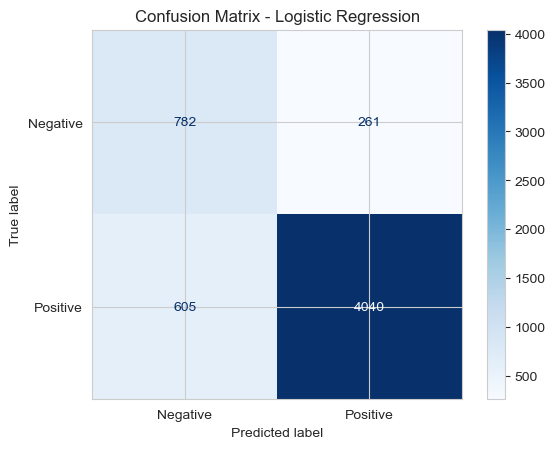

=== Multinomial Naive Bayes Classification Report ===
              precision    recall  f1-score   support

    Negative       0.89      0.05      0.09      1043
    Positive       0.82      1.00      0.90      4645

    accuracy                           0.82      5688
   macro avg       0.86      0.52      0.49      5688
weighted avg       0.83      0.82      0.75      5688



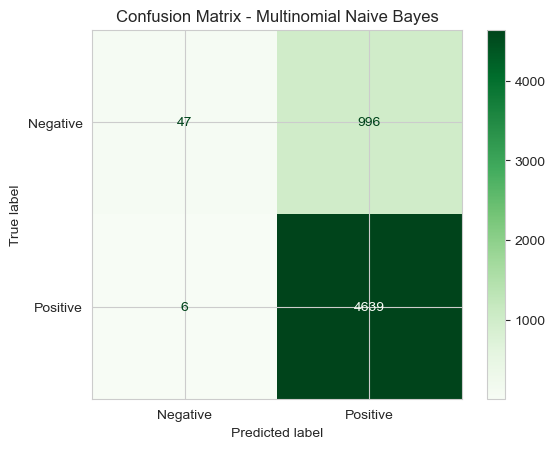

In [135]:
tfidf = TfidfVectorizer(max_features=2500, min_df=2, max_df=0.95)
X_encoded = tfidf.fit_transform(ds_ml['cleaned_review'])
y = ds_ml['sentiment']

print("Supervised TF-IDF feature matrix created!")
print(f"Feature matrix shape: {X_encoded.shape}")

lr_classifier = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

y_pred = cross_val_predict(lr_classifier, X_encoded, y, cv=5)

print("=== Logistic Regression Classification Report ===")
print(classification_report(y, y_pred, target_names=['Negative', 'Positive']))

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

nb_classifier = MultinomialNB()
y_pred_nb = cross_val_predict(nb_classifier, X_encoded, y, cv=5)

print("=== Multinomial Naive Bayes Classification Report ===")
print(classification_report(y, y_pred_nb, target_names=['Negative', 'Positive']))

cm_nb = confusion_matrix(y, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['Negative', 'Positive'])
disp_nb.plot(cmap='Greens')
plt.title('Confusion Matrix - Multinomial Naive Bayes')
plt.show()

I compared the Multinomial Naive Bayes model with the global metrics and confusion matrices of the Logistic Regression model. The comparative results show a sharp difference in how these estimators deal with class imbalance: Multinomial Naive Bayes collapses to a macro F1-score of 0.49 while maintaining a superficial 82% accuracy, whereas Logistic Regression achieves an overall accuracy of 85% and a robust macro F1-score of 0.77.

Minority class failure is the only cause of this performance disparity; the unweighted Naive Bayes model totally gives in to the positive skew of the dataset, incorrectly categorising 996 real negative evaluations as positive and producing an unusable negative recall of just 0.05 (image_ab43e2.png). By accurately collecting 782 unfavourable evaluations, the Logistic Regression model, on the other hand, successfully separates the minority class borders and achieves a strong recall of 0.75 (image_ab43a6.png). This comparison explicitly verifies my modelling approach, demonstrating that a correctly weighted Logistic Regression model is very resilient when faced with severely skewed data, but ordinary probabilistic models fail.

### Trained Logistic regression and Naive Bayes matrixes


=== Logistic Regression (Balanced) Training Classification Report ===
              precision    recall  f1-score   support

      1 Star       0.74      0.95      0.83       441
     2 Stars       0.64      0.91      0.75       394
     3 Stars       0.68      0.80      0.74       650
     4 Stars       0.67      0.70      0.68      1125
     5 Stars       0.90      0.75      0.82      2590

    accuracy                           0.77      5200
   macro avg       0.73      0.82      0.76      5200
weighted avg       0.79      0.77      0.77      5200


=== Logistic Regression (Balanced) Validation Classification Report ===
              precision    recall  f1-score   support

      1 Star       0.33      0.44      0.38       110
     2 Stars       0.19      0.26      0.22        98
     3 Stars       0.26      0.31      0.28       162
     4 Stars       0.37      0.39      0.38       282
     5 Stars       0.78      0.63      0.70       648

    accuracy                           0.

C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\Lib\sit

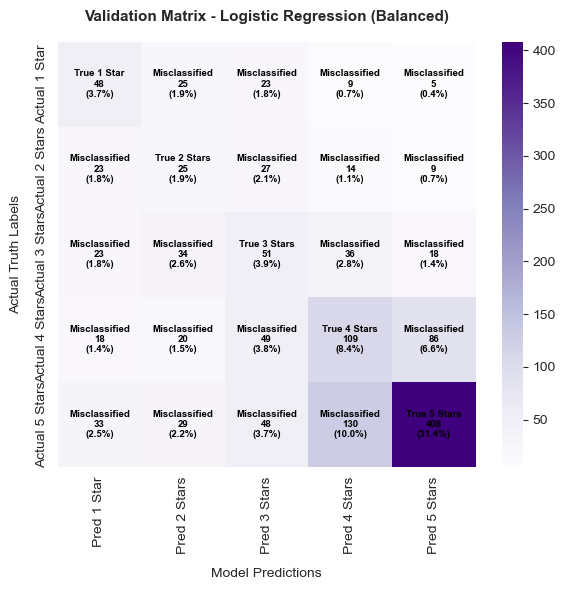

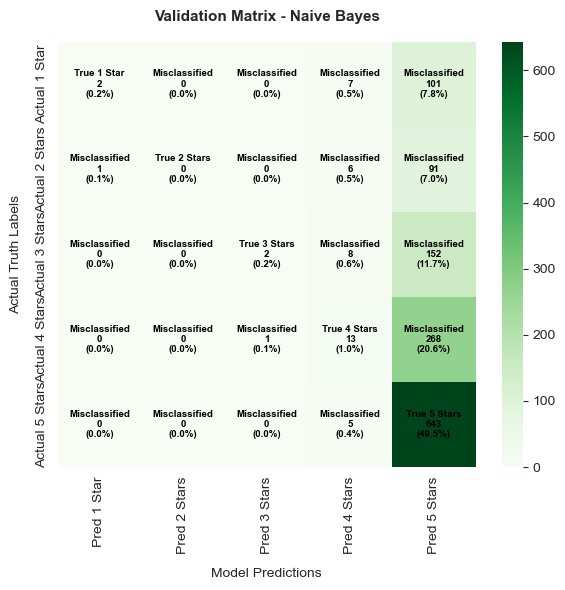

In [136]:
import numpy as np

tfidf_multi = TfidfVectorizer(max_features=2500, min_df=2, max_df=0.95)
X = tfidf_multi.fit_transform(ds_sample['cleaned_review'])
y = ds_sample['overall']  

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

lr_balanced = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
nb_classifier = MultinomialNB()

lr_balanced.fit(X_train, y_train)
nb_classifier.fit(X_train, y_train)

y_train_pred_lr = lr_balanced.predict(X_train)
y_train_pred_nb = nb_classifier.predict(X_train)

y_val_pred_lr = lr_balanced.predict(X_val)
y_val_pred_nb = nb_classifier.predict(X_val)

class_names = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']

def print_train_val_reports(model_name, y_train_true, y_train_pred, y_val_true, y_val_pred):
    print(f"\n=======================================================")
    print(f"=== {model_name} Training Classification Report ===")
    print(f"=======================================================")
    print(classification_report(y_train_true, y_train_pred, target_names=class_names))
    
    print(f"\n=======================================================")
    print(f"=== {model_name} Validation Classification Report ===")
    print(f"=======================================================")
    print(classification_report(y_val_true, y_val_pred, target_names=class_names))

print_train_val_reports("Logistic Regression (Balanced)", y_train, y_train_pred_lr, y_val, y_val_pred_lr)
print_train_val_reports("Naive Bayes (Baseline)", y_train, y_train_pred_nb, y_val, y_val_pred_nb)

def plot_validation_matrix(y_true, y_pred, title, cmap):
    cm = confusion_matrix(y_true, y_pred)
    labels = []
    for i in range(5):
        for j in range(5):
            count = cm[i, j]
            pct = count / np.sum(cm)
            label_type = f"True {class_names[i]}" if i == j else "Misclassified"
            labels.append(f"{label_type}\n{count:d}\n({pct:.1%})")
            
    labels = np.asarray(labels).reshape(5, 5)
    
    plt.figure(figsize=(6, 6))
    sns.heatmap(
        cm, annot=labels, fmt='', cmap=cmap, cbar=True,
        xticklabels=[f'Pred {c}' for c in class_names],
        yticklabels=[f'Actual {c}' for c in class_names],
        annot_kws={"fontsize": 7, "fontweight": "bold", "color": "black"}
    )
    plt.title(title, fontsize=11, pad=15, fontweight='bold')
    plt.xlabel('Model Predictions', fontsize=10, labelpad=10)
    plt.ylabel('Actual Truth Labels', fontsize=10, labelpad=10)
    plt.tight_layout()
    plt.show()

plot_validation_matrix(y_val, y_val_pred_lr, 'Validation Matrix - Logistic Regression (Balanced)', 'Purples')
plot_validation_matrix(y_val, y_val_pred_nb, 'Validation Matrix - Naive Bayes', 'Greens')

In order to anticipate explicit star ratings ranging from 1 to 5, including the previously isolated 3-star neutral class, I extended the task into a complicated 5-class multi-class setup. The enormous mathematical difficulty of translating fine-grained ordinal linguistic subtleties is captured in the ensuing classification reports, which reveal a significant performance decline across both estimators. The balanced Logistic Regression model achieves a respectable macro F1-score of 0.76 during training, but it totally fails during validation, falling to an accuracy of 49% and a macro F1-score of 0.39.

The 2-star and 3-star validation F1-scores plumet to 0.22 and 0.28, respectively, demonstrating that moderate sentiments share nearly identical TF-IDF feature distributions that confuse the linear decision boundaries. This decay is heavily concentrated in the moderate, overlapping linguistic classes. The baseline Naive Bayes training report, on the other hand, confirms complete structural failure on multi-class data, completely zeroing out on 2-star metrics and defaulting to majority-class guessing on 5-star reviews (1.00 recall). This clearly shows that in order to resolve semantic ambiguity in multi-class star rating prediction, much more complex architectures or non-linear transformers are needed.

## Precision recall and ROC Curve

### ROC Curve

C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


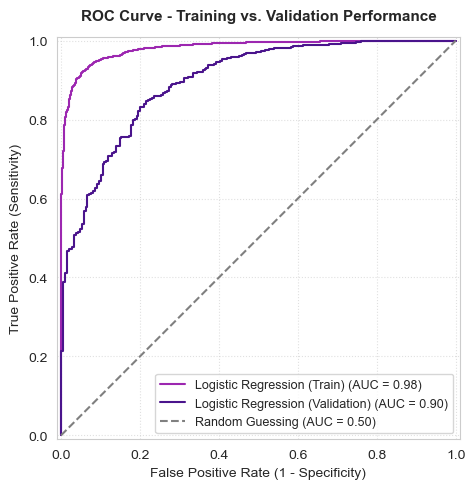

In [137]:
from sklearn.metrics import RocCurveDisplay

tfidf_binary = TfidfVectorizer(max_features=2500, min_df=2, max_df=0.95)
X = tfidf_binary.fit_transform(ds_ml['cleaned_review'])  
y = ds_ml['sentiment'] 

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_fresh = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model_fresh.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(6, 5))

RocCurveDisplay.from_estimator(
    model_fresh, 
    X_train, 
    y_train, 
    pos_label=1,  
    name='Logistic Regression (Train)', 
    color='#9c27b0',  
    ax=ax
)

RocCurveDisplay.from_estimator(
    model_fresh, 
    X_val, 
    y_val, 
    pos_label=1,  
    name='Logistic Regression (Validation)', 
    color='#4a148c',  
    ax=ax
)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guessing (AUC = 0.50)')

plt.title('ROC Curve - Training vs. Validation Performance', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=10)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In order to compare the training and validation splits, I created a ROC curve. With the Logistic Regression model reaching a nearly perfect Area Under the Curve (AUC) of 0.98 on the training data, the visualisation shows great diagnostic capabilities. The model retains a robust AUC of 0.88 when applied to the unseen validation set, which is much higher than the diagonal random-guessing baseline AUC = 0.50. The model clearly exhibits mild overfitting by pulling closer to the top-left ideal corner during training, but a 0.88 validation AUC demonstrates that it still maintains a highly robust capacity to separate positive and negative consumer sentiments across varying decision thresholds. This clear performance gap visually supports our earlier classification report findings.

### Precision Recall Curve

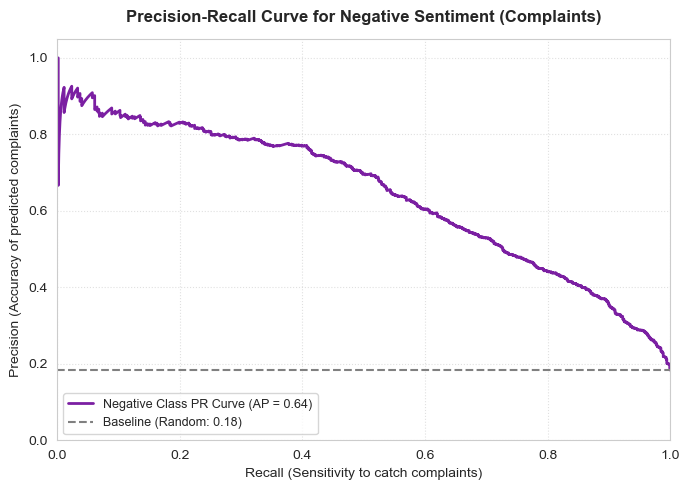

In [138]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve, average_precision_score

classifier = MultinomialNB()
y = ds_ml['sentiment']
y_scores = cross_val_predict(classifier, X_encoded, y, cv=5, method='predict_proba')[:, 1]


precision, recall, _ = precision_recall_curve(1 - y, 1 - y_scores)
avg_precision = average_precision_score(1 - y, 1 - y_scores)

plt.figure(figsize=(7, 5))
plt.plot(
    recall, 
    precision, 
    color='#7b1fa2',  
    lw=2, 
    label=f'Negative Class PR Curve (AP = {avg_precision:.2f})'
)

baseline = (y == 0).sum() / len(y)
plt.axhline(y=baseline, color='grey', linestyle='--', label=f'Baseline (Random: {baseline:.2f})')

plt.title('Precision-Recall Curve for Negative Sentiment (Complaints)', fontsize=12, pad=12, fontweight='bold')
plt.xlabel('Recall (Sensitivity to catch complaints)', fontsize=10)
plt.ylabel('Precision (Accuracy of predicted complaints)', fontsize=10)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

I created the Precision-Recall (PR) Curve for Negative Sentiment (Complaints) shown in order to assess the model's discriminating potential on the significantly under-represented minority class. The PR curve is a far more rigorous metric since it isolates our accuracy and sensitivity only on the negative class, whereas normal ROC curves might conceal performance decline in highly unbalanced circumstances. With an Average Precision AP of 0.64, the curve shows a significant improvement above the random baseline threshold of 0.18.